In [1]:
import numpy as np
import requests
import matplotlib.pyplot as plt

import matplotlib_inline.backend_inline

matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

plt.rcParams.update({
    'axes.spines.right': False,
    'axes.spines.top':   False,
    'axes.titleweight': 'bold',
    'axes.labelweight': 'bold',
    'savefig.dpi':300,  
})

In [2]:
from transformers import AutoTokenizer

tokenizer_G = AutoTokenizer.from_pretrained('gpt2')

c:\Users\PauloOliveira\py_studies\ml4llm\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
from transformers import BertTokenizer

tokenizer_B = BertTokenizer.from_pretrained('bert-base-uncased')

text = 'Peanut and strawberry'
tokens = tokenizer_B.encode(text)

print(f'Original text: \n {text}\n')
print(f'Token sequence:\n {tokens}\n')

for t in tokens:
    print(f'Token index {t:6} is "{tokenizer_B.decode(t)}"')
    

Original text: 
 Peanut and strawberry

Token sequence:
 [101, 21443, 1998, 16876, 102]

Token index    101 is "[CLS]"
Token index  21443 is "peanut"
Token index   1998 is "and"
Token index  16876 is "strawberry"
Token index    102 is "[SEP]"


In [4]:
print(tokenizer_B.decode(tokens[1:-1]))

tokens = tokenizer_B.encode(text, add_special_tokens=False)
print(tokenizer_B.decode(tokens))

peanut and strawberry
peanut and strawberry


In [5]:
dir(tokenizer_B)

['SPECIAL_TOKENS_ATTRIBUTES',
 '__annotations__',
 '__bool__',
 '__call__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__firstlineno__',
 '__format__',
 '__ge__',
 '__getattr__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__len__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__static_attributes__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_add_bos_token',
 '_add_eos_token',
 '_add_tokens',
 '_added_tokens_decoder',
 '_added_tokens_encoder',
 '_auto_class',
 '_convert_encoding',
 '_convert_id_to_token',
 '_convert_token_to_id_with_added_voc',
 '_decode',
 '_encode_plus',
 '_eventual_warn_about_too_long_sequence',
 '_extra_special_tokens',
 '_from_pretrained',
 '_get_files_timestamps',
 '_get_padding_truncation_strategies',
 '_in_target_context_manager',
 '_pad',
 '_pad_token_type_id',
 '_patc

In [6]:
print(f'BERT tokenizer has {tokenizer_B.vocab_size:,} tokens.')
print(f'GPT2 tokenizer has {tokenizer_G.vocab_size:,} tokens.')

BERT tokenizer has 30,522 tokens.
GPT2 tokenizer has 50,257 tokens.


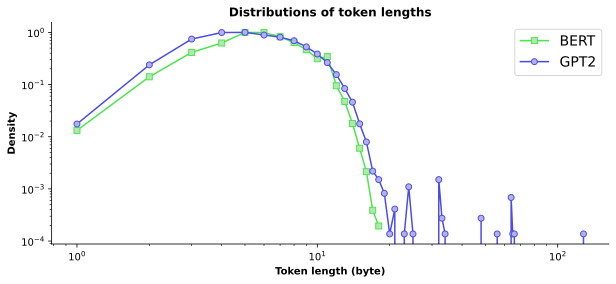

In [7]:
lengths_B = np.zeros(tokenizer_B.vocab_size, dtype=int)

for t in range(tokenizer_B.vocab_size):
    lengths_B[t] = len(tokenizer_B.decode(t).encode('utf-8'))

lengths_G = np.zeros(tokenizer_G.vocab_size, dtype=int)

for t in range(tokenizer_G.vocab_size):
    lengths_G[t] = len(tokenizer_G.decode(t).encode('utf-8'))

bincounts_B = np.bincount(lengths_B)
bincounts_G = np.bincount(lengths_G)

plt.figure(figsize=(10,4))
plt.plot(range(1,max(lengths_B)+1),bincounts_B[1:]/bincounts_B.max(),'s-',color=[.3,.9,.3],markerfacecolor=[.7,.9,.7],label='BERT')
plt.plot(range(1,max(lengths_G)+1),bincounts_G[1:]/bincounts_G.max(),'o-',color=[.3,.3,.9],markerfacecolor=[.7,.7,.9],label='GPT2')

plt.legend(fontsize=14)
plt.gca().set(xlabel='Token length (byte)',ylabel='Density', title='Distributions of token lengths',yscale='log',xscale='log')

plt.show()

In [8]:
baseurl = 'https://www.gutenberg.org/cache/epub/'

bookurls = [
    # code       title
    ['84',    'Frankenstein'    ],
    ['64317', 'GreatGatsby'     ],
    ['11',    'AliceWonderland' ],
    ['1513',  'RomeoJuliet'     ],
    ['76',    'HuckFinn'        ],
    ['219',   'HeartDarkness'   ],
    ['2591',  'GrimmsTales'     ],
    ['2148',  'EdgarAllenPoe'   ],
    ['36',    'WarOfTheWorlds'  ],
    ['829',   'GulliversTravels']
]

In [9]:
tokens_B = np.zeros(len(bookurls))
tokens_G = np.zeros(len(bookurls))
token_lens_B = np.zeros(len(bookurls))
token_lens_G = np.zeros(len(bookurls))

for i, (code, title) in enumerate(bookurls):
    fullurl = baseurl + code + '/pg' + code + '.txt'
    text = requests.get(fullurl).text

    brt_toks = tokenizer_B.encode(text, add_special_tokens=False)
    gpt_toks = tokenizer_G.encode(text)

    tokens_B[i] = len(brt_toks)
    tokens_G[i] = len(gpt_toks)

    token_lens_B[i] = np.mean([len(tokenizer_B.decode(t).encode('utf-8')) for t in brt_toks])
    token_lens_G[i] = np.mean([len(tokenizer_G.decode(t).encode('utf-8')) for t in gpt_toks])

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (96279 > 512). Running this sequence through the model will result in indexing errors
[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (114213 > 1024). Running this sequence through the model will result in indexing errors


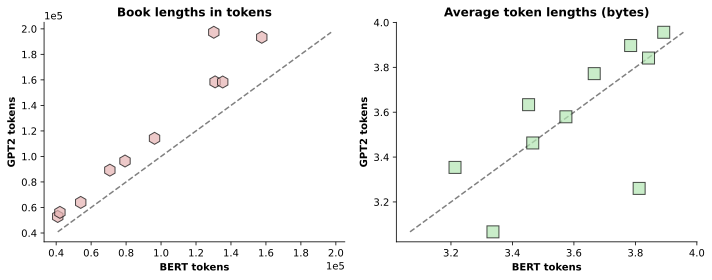

In [10]:
_, axs = plt.subplots(1, 2, figsize=(10,4))

axs[0].plot(tokens_B, tokens_G, 'kh', markerfacecolor=[.9, .7, .7, .7], markersize=12)

minlength = np.min([np.min(tokens_B), np.min(tokens_G)])
maxlength = np.max([np.max(tokens_B), np.max(tokens_G)])
axs[0].plot([minlength, maxlength], [minlength, maxlength], '--', color=[.5, .5, .5])

axs[0].set(xlabel='BERT tokens',ylabel='GPT2 tokens',title='Book lengths in tokens')
axs[0].ticklabel_format(style='scientific',axis='both',scilimits=(0,0))

axs[1].plot(token_lens_B,token_lens_G,'ks',markerfacecolor=[.7,.9,.7,.7],markersize=12)

minlength = np.min([np.min(token_lens_B),np.min(token_lens_G)])
maxlength = np.max([np.max(token_lens_B),np.max(token_lens_G)])
axs[1].plot([minlength,maxlength],[minlength,maxlength],'--',zorder=-10,color=[.5,.5,.5])

axs[1].set(xlabel='BERT tokens',ylabel='GPT2 tokens',title='Average token lengths (bytes)')


plt.tight_layout()
plt.show()


In [11]:
def GPT_to_BERT(toks):
  newtxt  = tokenizer_G.decode(toks)
  newtoks = tokenizer_B.encode(newtxt,add_special_tokens=False)
  return newtoks

def BERT_to_GPT(t):
  return tokenizer_G.encode( tokenizer_B.decode(t),add_special_tokens=False )

In [12]:
text = 'Canadian winters are kept WArM bY the friendliness of THE PEOPLE.'
print('Original text:\n ',text,'\n')

toks_B = tokenizer_B.encode(text,add_special_tokens=False)
toks_G = tokenizer_G.encode(text)

print('BERT tokens:\n ',toks_B)
print('GPT2 tokens:\n ',toks_G,'\n')

print('BERT reconstruction:\n ',tokenizer_B.decode(toks_B))
print('GPT2 reconstruction:\n ',tokenizer_G.decode(toks_G),'\n')

print('BERT to GPT2 translation:\n ',tokenizer_G.decode(BERT_to_GPT(toks_B)))
print('GPT2 to BERT translation:\n ',tokenizer_B.decode(GPT_to_BERT(toks_G)))

Original text:
  Canadian winters are kept WArM bY the friendliness of THE PEOPLE. 

BERT tokens:
  [3010, 12214, 2024, 2921, 4010, 2011, 1996, 2767, 20942, 1997, 1996, 2111, 1012]
GPT2 tokens:
  [28203, 45764, 389, 4030, 370, 3163, 44, 275, 56, 262, 1545, 26061, 286, 3336, 36388, 13] 

BERT reconstruction:
  canadian winters are kept warm by the friendliness of the people.
GPT2 reconstruction:
  Canadian winters are kept WArM bY the friendliness of THE PEOPLE. 

BERT to GPT2 translation:
  canadian winters are kept warm by the friendliness of the people.
GPT2 to BERT translation:
  canadian winters are kept warm by the friendliness of the people.
